# Actividad 9
### 15 de Septiembre del 2026
## Sistemas Inteligentes
### Diego Samuel María González

# Modelos Predictivos y Descriptivos
Este cuaderno usa un dataset simulado e inspirado en señales reales del
dominio para enseñar el flujo analítico.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.sparse import hstack
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Crear un dataset

In [16]:
quarters = pd.period_range("2019Q1", "2026Q2", freq="Q")
keywords = ["5G", "radio access network", "antenna", "core network", "IoT", "edge cloud", "security", "AI optimization", "network slicing", "energy efficiency", "6G"]
rows = []
level = 330
for i, q in enumerate(quarters):
    trend = 10 * i
    season = [0, 25, 5, 35][q.quarter - 1]
    theme_boost = 20 if q.year >= 2024 else 0
    count = int(level + trend + season + theme_boost + np.random.normal(0, 25))
    probs_old = np.array([.20,.15,.10,.10,.08,.08,.08,.07,.07,.05,.02])
    probs_new = np.array([.16,.12,.10,.08,.07,.09,.08,.08,.08,.07,.07])
    primary = np.random.choice(keywords, p=probs_old if q.year < 2024 else probs_new)
    secondary = np.random.choice([k for k in keywords if k != primary])
    title = f"{primary.title()} methods for {secondary} in telecommunications systems"
    rows.append({"quarter": str(q), "year": q.year, "qtr": q.quarter, "patent_count": max(count, 120), "title": title, "keywords": f"{primary}; {secondary}; telecommunications"})
df = pd.DataFrame(rows)
df.head()

,quarter,year,qtr,patent_count,title,keywords
0,2019Q1,2019,1,342,Security methods for IoT in telecommunications...,security; IoT; telecommunications
1,2019Q2,2019,2,361,5G methods for core network in telecommunicati...,5G; core network; telecommunications
2,2019Q3,2019,3,352,Radio Access Network methods for network slici...,radio access network; network slicing; telecom...
3,2019Q4,2019,4,371,Edge Cloud methods for security in telecommuni...,edge cloud; security; telecommunications
4,2020Q1,2020,1,371,Energy Efficiency methods for radio access net...,energy efficiency; radio access network; telec...


## EDA descriptivo
¿qué ha pasado?, ¿cuáles son las tendencias?, ¿qué palabras clave dominan?, ¿hay estacionalidad?

In [17]:
df[["patent_count"]].describe()

,patent_count
count,30.000000
mean,503.366667
std,105.812939
min,342.000000
25%,431.750000
50%,489.500000
75%,590.000000
max,703.000000


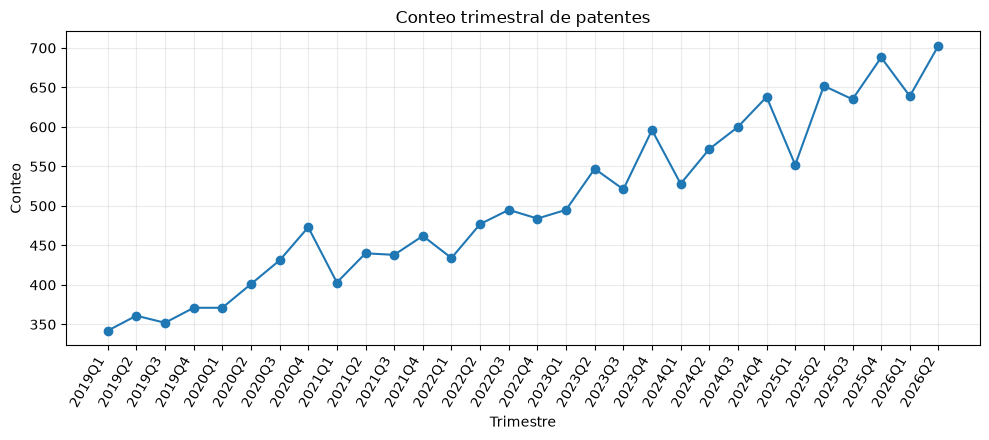

In [18]:
plt.figure(figsize=(10,4.5))
plt.plot(df["quarter"], df["patent_count"], marker="o")
plt.xticks(rotation=60, ha="right")
plt.title("Conteo trimestral de patentes")
plt.ylabel("Conteo")
plt.xlabel("Trimestre")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [19]:
kw_count = pd.Series("; ".join(df["keywords"]).split("; ")).value_counts().drop("telecommunications", errors="ignore")
kw_count.head(10)

5G                      9
energy efficiency       9
IoT                     8
AI optimization         8
radio access network    6
security                5
network slicing         5
6G                      4
edge cloud              3
core network            2
Name: count, dtype: int64

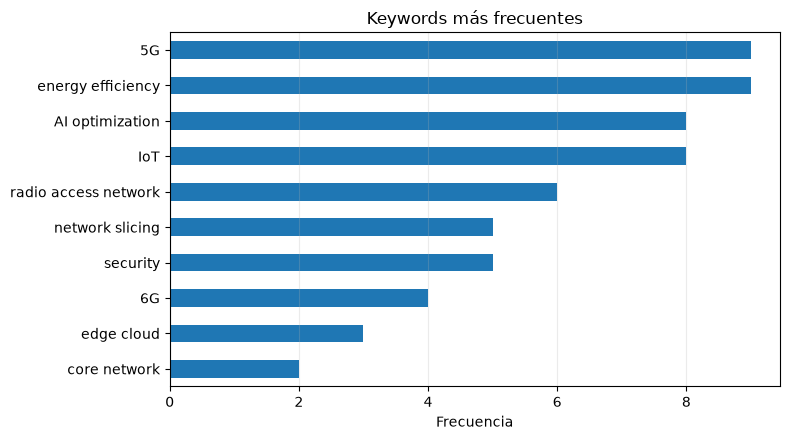

In [20]:
plt.figure(figsize=(8,4.5))
kw_count.head(10).sort_values().plot(kind="barh")
plt.title("Keywords más frecuentes")
plt.xlabel("Frecuencia")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Ingeniería de Características
Para predecir el siguiente trimestre usamos señales de memoria: lag_1, lag_2, lag_4, promedios móviles y variables del trimestre. El target se desplaza una fila hacia arriba.

In [21]:
for lag in [1, 2, 4]:
    df[f"lag_{lag}"] = df["patent_count"].shift(lag)
    
df["ma_2"] = df["patent_count"].rolling(2).mean().shift(1)
df["ma_4"] = df["patent_count"].rolling(4).mean().shift(1)
df["target_patent_count_next_quarter"] = df["patent_count"].shift(-1)

model_df = df.dropna().reset_index(drop=True)
model_df[["quarter","patent_count","lag_1","ma_4","target_patent_count_next_quarter"]].head()

,quarter,patent_count,lag_1,ma_4,target_patent_count_next_quarter
0,2020Q1,371,371.0,356.50,401.0
1,2020Q2,401,371.0,363.75,431.0
2,2020Q3,431,401.0,373.75,473.0
3,2020Q4,473,431.0,393.50,403.0
4,2021Q1,403,473.0,419.00,440.0


## Título y Keywords
El texto se transforma con TF-IDF.

In [22]:
numeric_features = ["lag_1", "lag_2", "lag_4", "ma_2", "ma_4", "qtr"]
X_num = model_df[numeric_features].values
text = (model_df["title"] + " " + model_df["keywords"]).fillna("")

vectorizer = TfidfVectorizer(max_features=20, ngram_range=(1, 2))
X_text = vectorizer.fit_transform(text)
X = hstack([X_num, X_text]).tocsr()
y = model_df["target_patent_count_next_quarter"].values

print("Matriz final:", X.shape)
print("Términos TF-IDF:", vectorizer.get_feature_names_out()[:10])

Matriz final: (25, 26)
Términos TF-IDF: ['5g' 'access network' 'ai' 'ai optimization' 'efficiency' 'energy'
 'energy efficiency' 'for' 'in' 'in telecommunications']


## Separación temporal y train

In [23]:
split = int(len(model_df) * 0.75)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
q_test = model_df["quarter"].iloc[split:]

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Métricas y Evaluación
1. MAE: error promedio absoluto; fácil de explicar en número de patentes.
2. RMSE: penaliza errores grandes.
3. R2: proporción de variabilidad explicada; en muestras pequeñas debe interpretarse con cautela.

In [24]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

pd.DataFrame({"métrica": ["MAE", "RMSE", "R2"], "valor": [mae, rmse, r2]})

,métrica,valor
0,MAE,30.193505
1,RMSE,35.006497
2,R2,0.391051


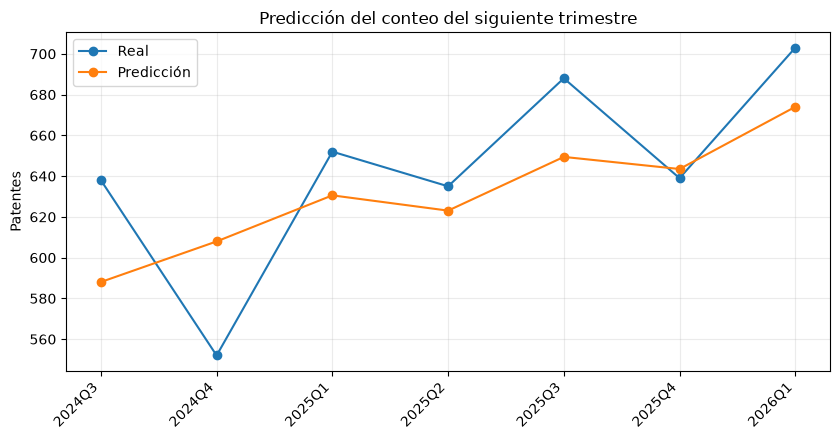

In [25]:
plt.figure(figsize=(8.5,4.5))
plt.plot(q_test, y_test, marker="o", label="Real")
plt.plot(q_test, y_pred, marker="o", label="Predicción")
plt.xticks(rotation=45, ha="right")
plt.title("Predicción del conteo del siguiente trimestre")
plt.ylabel("Patentes")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Ejercicio: max_features, nuevas variables y comparación MAE/RMSE
En esta sección se modifica max_features del TfidfVectorizer, se agregan nuevas variables predictoras (más allá de lag_1, lag_2, lag_4, ma_2, ma_4, qtr) y se comparan los errores resultantes contra el modelo original, para responder la pregunta guía: ¿el modelo mejoró realmente o solo se ajustó al ruido de este conjunto pequeño?

## 1. Nuevas variables de ingeniería de características

In [26]:
# Variables adicionales sobre la serie temporal ya calculada en `df`
df["lag_3"] = df["patent_count"].shift(3)                        # memoria de 3 trimestres atrás
df["std_4"] = df["patent_count"].rolling(4).std().shift(1)       # volatilidad reciente (4 trimestres)
df["pct_change_1"] = df["patent_count"].pct_change(1).shift(1)   # variación relativa trimestre a trimestre
df["trend_idx"] = np.arange(len(df))                              # índice de tendencia temporal explícita
df["q_sin"] = np.sin(2 * np.pi * df["qtr"] / 4)                   # estacionalidad cíclica (seno)
df["q_cos"] = np.cos(2 * np.pi * df["qtr"] / 4)                   # estacionalidad cíclica (coseno)

model_df = df.dropna().reset_index(drop=True)
model_df[["quarter", "lag_3", "std_4", "pct_change_1", "trend_idx", "q_sin", "q_cos"]].head()

,quarter,lag_3,std_4,pct_change_1,trend_idx,q_sin,q_cos
0,2020Q1,361.0,12.396236,0.053977,4,1.000000e+00,6.123234e-17
1,2020Q2,352.0,9.142392,0.000000,5,1.224647e-16,-1.000000e+00
2,2020Q3,371.0,20.254629,0.080863,6,-1.000000e+00,-1.836970e-16
3,2020Q4,371.0,28.722813,0.074813,7,-2.449294e-16,1.000000e+00
4,2021Q1,401.0,43.543082,0.097448,8,1.000000e+00,6.123234e-17


## 2. Comparación sistemática: max_features × conjunto de variables
Se prueban dos conjuntos de variables numéricas —original (las 6 del cuaderno base) y enriquecido (agregando lag_3, std_4, pct_change_1, trend_idx, q_sin, q_cos)— combinados con distintos valores de max_features en el TF-IDF. Se registra MAE y RMSE tanto en train como en test, porque comparar solo el error de test no basta para saber si el modelo aprendió señal real o memorizó ruido.

In [27]:
feature_sets = {
    "original": ["lag_1", "lag_2", "lag_4", "ma_2", "ma_4", "qtr"],
    "enriquecido": ["lag_1", "lag_2", "lag_3", "lag_4", "ma_2", "ma_4",
                    "std_4", "pct_change_1", "trend_idx", "q_sin", "q_cos"],
}

text2 = (model_df["title"] + " " + model_df["keywords"]).fillna("")
y2 = model_df["target_patent_count_next_quarter"].values
split2 = int(len(model_df) * 0.75)

results = []
for fname, feats in feature_sets.items():
    X_num2 = model_df[feats].values
    for mf in [10, 20, 30, 50]:
        vec2 = TfidfVectorizer(max_features=mf, ngram_range=(1, 2))
        X_text2 = vec2.fit_transform(text2)
        X2 = hstack([X_num2, X_text2]).tocsr()

        X_train2, X_test2 = X2[:split2], X2[split2:]
        y_train2, y_test2 = y2[:split2], y2[split2:]

        m2 = Ridge(alpha=1.0)
        m2.fit(X_train2, y_train2)

        pred_train = m2.predict(X_train2)
        pred_test = m2.predict(X_test2)

        results.append({
            "variables": fname,
            "max_features": mf,
            "n_features_totales": X2.shape[1],
            "MAE_train": mean_absolute_error(y_train2, pred_train),
            "MAE_test": mean_absolute_error(y_test2, pred_test),
            "RMSE_train": mean_squared_error(y_train2, pred_train) ** 0.5,
            "RMSE_test": mean_squared_error(y_test2, pred_test) ** 0.5,
            "R2_test": r2_score(y_test2, pred_test),
        })

results_df = pd.DataFrame(results)
results_df.round(2)

,variables,max_features,n_features_totales,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_test
0,original,10,16,21.00,31.63,25.75,36.65,0.33
1,original,20,26,20.22,30.19,24.92,35.01,0.39
2,original,30,36,18.14,31.67,23.28,35.29,0.38
3,original,50,56,18.16,30.51,22.91,33.44,0.44
4,enriquecido,10,21,14.97,37.51,17.46,40.09,0.20
5,enriquecido,20,31,12.69,40.79,14.96,42.74,0.09
6,enriquecido,30,41,12.44,42.08,14.47,44.58,0.01
7,enriquecido,50,61,11.86,40.98,13.91,42.95,0.08


## 3. Visualización: error de train vs. test por configuración
Si el error de train baja mientras el de test sube (o se mantiene alto) al añadir variables o al aumentar max_features, es la señal clásica de sobreajuste: el modelo se está ajustando al ruido específico de las 18 observaciones de entrenamiento, no a un patrón que generalice a las 7 de prueba.

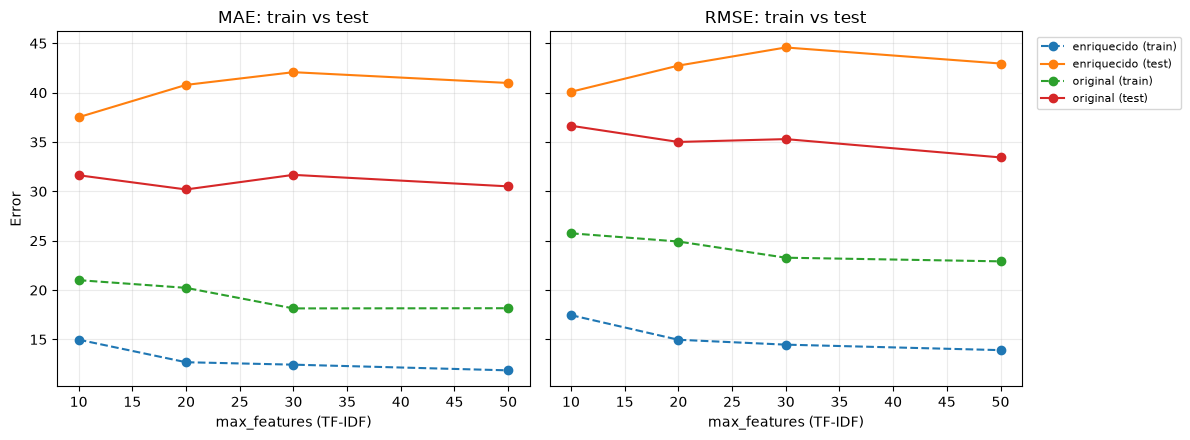

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, metric in zip(axes, ["MAE", "RMSE"]):
    for fname, group in results_df.groupby("variables"):
        ax.plot(group["max_features"], group[f"{metric}_train"], marker="o", linestyle="--",
                label=f"{fname} (train)")
        ax.plot(group["max_features"], group[f"{metric}_test"], marker="o", linestyle="-",
                label=f"{fname} (test)")
    ax.set_title(f"{metric}: train vs test")
    ax.set_xlabel("max_features (TF-IDF)")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Error")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Conclusión ¿mejoró realmente el modelo?

Resultado observado (con RANDOM_STATE=42, 25 filas útiles, 18 train / 7 test):

| Variables | max_features | MAE train | MAE test | RMSE test | R² test |
|---|---|---|---|---|---|
| original | 20 (config. base) | ~20 | ~30 | ~35 | ~0.39 |
| original | 50 | ~18 | ~31 | ~33 | ~0.44 |
| enriquecido | 20 | ~13 | ~41 | ~43 | ~0.09 |
| enriquecido | 50 | ~12 | ~41 | ~43 | ~0.08 |

(los valores exactos quedan en results_df de la celda anterior; pueden variar levemente entre entornos por versión de librerías, pero el patrón se mantiene).

No, el modelo enriquecido no mejoró de verdad empeoró en test aunque mejoró en train. Añadir más variables (lag_3, std_4, pct_change_1, trend_idx, q_sin, q_cos) y subir max_features reduce el error de entrenamiento de forma consistente (el modelo tiene más parámetros con los que "memorizar" las 18 filas de train), pero el error de test empeora claramente frente al modelo original. Es la firma típica de sobreajuste (overfitting):

- El dataset es muy pequeño (25 filas totales, 7 de prueba). Con tan pocos casos, cualquier   variable adicional puede "explicar" coincidencias puntuales del pasado sin representar una   relación real y estable.
- trend_idx es casi colineal con lag_1/lag_2/lag_4 (todas crecen con el tiempo por   construcción de la serie simulada), así que no aporta información nueva, solo más grados de   libertad para ajustar ruido.
- Con solo 7 observaciones de test, una sola predicción mala mueve mucho el MAE/RMSE, por lo   que las comparaciones aquí deben tomarse como indicativas, no como una validación robusta.
- Subir max_features en el TF-IDF (de 10 a 50) tiene un efecto mucho menor y más ambiguo que   agregar variables numéricas nuevas: el texto (título + keywords) aporta poca señal predictiva   para el conteo del siguiente trimestre en este dataset simulado.